# 03 · Error, conditioning, stability, and cancellation

**Time:** 110–120 minutes; the last two experiments are optional extensions.
**Prerequisites:** Lecture 02, first derivatives, quadratic equations.
**Lab:** [Equivalent formulas, different answers](../labs/lab03_stability.ipynb).

Objectives: quantify error with an appropriate reference; distinguish sensitivity
of a problem from stability of an algorithm; recognize cancellation; compare
reformulation, compensated summation, and increased precision.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'notebooks'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
import math
from decimal import Decimal, localcontext
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from vc.environment import require_binary64

require_binary64()

## THEORY · Forward error, backward error, and conditioning

For exact data $x$, desired answer $y=f(x)$, and computed answer $\widehat y$:

- Absolute forward error is $|\widehat y-y|$; relative forward error divides
  this by $|y|$ and is undefined when $y=0$.
- A backward error measures a change $\Delta x$ for which
  $\widehat y=f(x+\Delta x)$. Its size must be judged against a stated input scale.
- Conditioning asks how much the *exact* answer changes when the input changes.
- Stability asks whether an algorithm introduces acceptably small errors,
  often described through a small backward error.

**First-order sensitivity.** If $f$ is differentiable at $x$, and $x$ and $f(x)$
are nonzero, then for small relative perturbations $\eta$,

$$\frac{f(x(1+\eta))-f(x)}{f(x)}
  =\frac{x f'(x)}{f(x)}\eta+o(\eta).$$

**Derivation.** Substitute $\Delta x=x\eta$ into
$f(x+\Delta x)=f(x)+f'(x)\Delta x+o(\Delta x)$, then divide by $f(x)$.
Thus $\kappa_f(x)=|xf'(x)/f(x)|$ is a local relative condition number.
This asymptotic estimate is not a rigorous finite-perturbation bound unless we
also bound the remainder or the derivative over the relevant interval.

In [3]:
x = Fraction(1000001, 1000000)
perturbation = Fraction(1, 10**9)
f = lambda t: t - 1
input_relative = perturbation / x
output_relative = abs((f(x + perturbation) - f(x)) / f(x))
print("Relative input change:", float(input_relative))
print("Relative output change:", float(output_relative))
print("Exact amplification:", output_relative / input_relative)

Relative input change: 9.99999000001e-10
Relative output change: 0.001
Exact amplification: 1000001


## EXPERIMENT · A concrete backward error

Suppose $\widehat y\geq0$ approximates $\sqrt a$. Define
$\Delta a=\widehat y^2-a$. Then $\widehat y=\sqrt{a+\Delta a}$ exactly:
the computed number solves a nearby input problem. We can compute this input
perturbation exactly for a stored binary float. It is a property of this answer,
not a proof that every call to the square-root algorithm is backward stable.

In [4]:
datum = Fraction(2)
computed = Fraction.from_float(math.sqrt(2.0))
backward_error = computed**2 - datum
assert computed**2 == datum + backward_error
print("Exact input perturbation:", backward_error)
print("Relative backward error≈", float(abs(backward_error) / datum))

Exact input perturbation: 5545866846675497/20282409603651670423947251286016
Relative backward error≈ 1.3671617315323846e-16


## THEORY · Why subtraction exposes error

Suppose the operands are already perturbed to $a+e_a$ and $b+e_b$. Before even
rounding the subtraction, its error is $e_a-e_b$. Hence

$$\frac{|e_a-e_b|}{|a-b|}\leq\frac{|e_a|+|e_b|}{|a-b|}.$$

A small difference can have a large relative error. The subtraction itself may
even be exact on the stored operands; lost information in those operands is not
restored by subtracting them. Cancellation is a reason to inspect the whole
expression, not to prohibit all subtraction.

## EXPERIMENT · A reasonable-looking polynomial (Tucker, Example 1.6.2)

All three formulas below represent $p(t)=(t-1)^6$. Near 1, its true value is
extremely small compared with the terms in its expanded form.

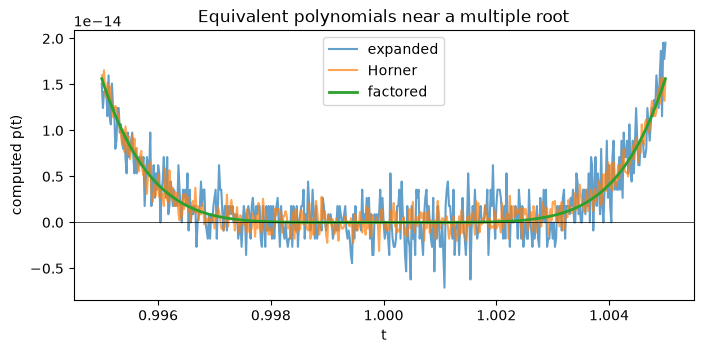

In [5]:
def expanded(t):
    return t**6 - 6*t**5 + 15*t**4 - 20*t**3 + 15*t**2 - 6*t + 1

def horner(t):
    coefficients = [1, -6, 15, -20, 15, -6, 1]
    result = coefficients[0]
    for coefficient in coefficients[1:]:
        result = result * t + coefficient
    return result

def factored(t):
    return (t - 1)**6

ts = np.linspace(0.995, 1.005, 501)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ts, expanded(ts), label="expanded", alpha=0.7)
ax.plot(ts, horner(ts), label="Horner", alpha=0.7)
ax.plot(ts, factored(ts), label="factored", linewidth=2)
ax.axhline(0, color="black", linewidth=0.5)
ax.set(xlabel="t", ylabel="computed p(t)", title="Equivalent polynomials near a multiple root")
ax.legend()
display(fig)
plt.close(fig)

We can measure exact evaluation errors **at the same stored binary input**.
Using `Fraction.from_float(t)` avoids confusing input representation error with
evaluation error. Decimal output below is for readability; the comparisons use
exact rationals.

In [6]:
t = 1.001
exact_t = Fraction.from_float(t)
reference = (exact_t - 1)**6
assert expanded(exact_t) == horner(exact_t) == reference
for name, method in [("expanded", expanded), ("Horner", horner), ("factored", factored)]:
    result = float(method(t))
    error = abs(Fraction.from_float(result) - reference)
    print(f"{name:9}: result={result:.5e}, abs error≈{float(error):.3e}, "
          f"relative error≈{float(error/reference):.3e}")

expanded : result=-2.66454e-15, abs error≈2.666e-15, relative error≈2.666e+03
Horner   : result=-6.66134e-16, abs error≈6.671e-16, relative error≈6.671e+02
factored : result=1.00000e-18, abs error≈8.972e-35, relative error≈8.972e-17


Horner reduces operation count but does not remove the cancellation near this
root. Factoring is a much better evaluation strategy here. Separately, the
problem has $\kappa_p(t)=|6t/(t-1)|$ for $t\ne1$, so uncertainty in $t$ can
still produce a large relative change in the true answer. A better algorithm
does not change that mathematical sensitivity.

**EXERCISE (10 minutes):** why are relative errors at $t=1$ inappropriate?
Does a negative computed value prove that this polynomial is negative anywhere?

## EXPERIMENT · Rationalize a difference of square roots

For $x\geq0$, multiplying numerator and denominator by the conjugate gives

$$\sqrt{x+1}-\sqrt{x}=\frac{1}{\sqrt{x+1}+\sqrt{x}}.$$

The second formula avoids subtracting two close computed square roots. We use
an 80-digit Decimal computation as a labelled *approximate* reference. It is
adequate for comparison here, but we have not attached a rigorous error bound.

In [7]:
for x in [1.0, 1e8, 1e16]:
    naive = math.sqrt(x + 1) - math.sqrt(x)
    stable = 1 / (math.sqrt(x + 1) + math.sqrt(x))
    with localcontext() as dc:
        dc.prec = 80
        xd = Decimal.from_float(x)
        reference_decimal = 1 / ((xd + 1).sqrt() + xd.sqrt())
        naive_error = abs(Decimal.from_float(naive) - reference_decimal)
        stable_error = abs(Decimal.from_float(stable) - reference_decimal)
    print(f"x={x:g}: naive={naive:.8g}, reformulated={stable:.8g}")
    print(f"  approximate errors: {naive_error:.2E}, {stable_error:.2E}")

x=1: naive=0.41421356, reformulated=0.41421356
  approximate errors: 9.67E-17, 4.12E-17
x=1e+08: naive=5.0000001e-05, reformulated=5e-05
  approximate errors: 6.81E-13, 4.51E-21
x=1e+16: naive=0, reformulated=5e-09
  approximate errors: 5.00E-9, 2.30E-25


## THEORY + EXPERIMENT · Quadratic roots

For $a\ne0$ and nonnegative discriminant $D=b^2-4ac$, the usual formula can
subtract nearly equal values. Define

$$q=-\tfrac12\bigl(b+\operatorname{copysign}(\sqrt D,b)\bigr),
\qquad x_1=q/a,\quad x_2=c/q.$$

The first numerator adds quantities with the same sign. The second root follows
from $x_1x_2=c/a$. Handle linear, repeated-root, and zero-root cases separately.
The implementation below teaches cancellation avoidance for moderate finite
coefficients; it does not promise a general overflow/underflow-safe solver or
certify the discriminant sign near a multiple root.

In [8]:
def real_quadratic_roots(a, b, c):
    a, b, c = float(a), float(b), float(c)
    if not all(math.isfinite(value) for value in [a, b, c]):
        raise ValueError("Finite coefficients required")
    if a == 0:
        if b == 0:
            if c == 0:
                raise ValueError("Every real number is a solution")
            return ()
        return (-c / b,)
    if c == 0:
        return (0.0, -b / a)
    discriminant = b*b - 4*a*c
    if not math.isfinite(discriminant):
        raise ValueError("Rescaling is needed outside this teaching example's range")
    if discriminant < 0:
        return ()
    if discriminant == 0:
        root = -b / (2*a)
        return (root, root)
    q = -0.5 * (b + math.copysign(math.sqrt(discriminant), b))
    return (q / a, c / q)

a, b, c = 1.0, 1e8, 1.0
D = b*b - 4*a*c
naive_small = (-b + math.sqrt(D)) / (2*a)
stable_small = min(real_quadratic_roots(a, b, c), key=abs)
with localcontext() as dc:
    dc.prec = 80
    ad, bd, cd = map(Decimal.from_float, (a, b, c))
    small_reference = (-bd + (bd*bd - 4*ad*cd).sqrt()) / (2*ad)
    for name, root in [("naive", naive_small), ("reformulated", stable_small)]:
        rel = abs((Decimal.from_float(root) - small_reference) / small_reference)
        print(name, root, "relative error against 80-digit approximation:", f"{rel:.3E}")

naive -7.450580596923828e-09 relative error against 80-digit approximation: 2.549E-1
reformulated -1e-08 relative error against 80-digit approximation: 7.908E-17


In [9]:
assert real_quadratic_roots(0, 2, -4) == (2.0,)
assert real_quadratic_roots(0, 0, 1) == ()
assert real_quadratic_roots(1, 0, 0) == (0.0, -0.0)
assert real_quadratic_roots(1, 2, 1) == (-1.0, -1.0)
assert set(real_quadratic_roots(1, 0, -1)) == {-1.0, 1.0}
assert real_quadratic_roots(1, 0, 1) == ()

**Checkpoint:** why does using `sign(b)` carelessly fail when $b=0$? Why does
computing more digits not settle whether measured coefficients have a double root?

## EXPERIMENT · Summation order and compensation

We implement an explicit left-to-right loop. Python's built-in `sum` may use
a more accurate implementation, so it should not stand in for that algorithm.
In Kahan summation, a compensation variable tracks low-order information lost
during a previous addition. It improves many sums but is not a universal guarantee.

In [10]:
def naive_sum(values):
    total = 0.0
    for value in values:
        total += value
    return total

def kahan_sum(values):
    total = 0.0
    correction = 0.0
    for value in values:
        adjusted = value - correction
        updated = total + adjusted
        correction = (updated - total) - adjusted
        total = updated
    return total

values = [1.0] + [2.0**-54] * 10000
exact_sum = Fraction(1) + 10000 * Fraction(1, 2**54)
for name, method in [("naive", naive_sum), ("reversed naive", lambda v: naive_sum(v[::-1])),
                     ("Kahan", kahan_sum), ("math.fsum", math.fsum)]:
    answer = method(values)
    error = abs(Fraction.from_float(answer) - exact_sum)
    print(name, answer, "exact absolute error:", error)

naive 1.0 exact absolute error: 625/1125899906842624
reversed naive 1.0000000000005551 exact absolute error: 0
Kahan 1.0000000000005551 exact absolute error: 0
math.fsum 1.0000000000005551 exact absolute error: 0


In [11]:
hard_values = [1e16, 1.0, -1e16]
print("Kahan on a difficult order:", kahan_sum(hard_values))
print("Exact sum:", sum(map(Fraction.from_float, hard_values), Fraction(0)))
print("math.fsum:", math.fsum(hard_values))

Kahan on a difficult order: 0.0
Exact sum: 1
math.fsum: 1.0


## Optional · Rump's expression (Tucker, Example 1.6.1)

Large intermediate terms can nearly cancel even when all coefficients and inputs
are exactly representable. Historical outputs vary by machine and compiler.
We evaluate our own expression and compare with an exact rational answer.
The division order below is explicit; other algebraic evaluation orders may give
other floating-point answers.

In [12]:
def rump(x, y):
    return (1335*y**6)/4 + x*x*(11*x*x*y*y - y**6 - 121*y**4 - 2) + (11*y**8)/2 + x/(2*y)

xq, yq = Fraction(77617), Fraction(33096)
exact_rump = rump(xq, yq)
assert exact_rump == -2 + xq/(2*yq)
print("Exact answer:", exact_rump, "approximately", float(exact_rump))
print("Binary64 evaluation:", rump(float(xq), float(yq)))

Exact answer: -54767/66192 approximately -0.8273960599468214
Binary64 evaluation: -1.1805916207174113e+21


We can vary binary precision with MPFR. Every value in this table remains a
rounded approximation. Here the exact rational provides a genuine error check;
agreement between successive rows alone would not provide one.

In [13]:
import gmpy2
for bits in [53, 80, 128, 256]:
    with gmpy2.context(precision=bits, round=gmpy2.RoundToNearest):
        answer = rump(gmpy2.mpfr(77617), gmpy2.mpfr(33096))
        n, d = answer.as_integer_ratio()
        exact_error = abs(Fraction(int(n), int(d)) - exact_rump)
        print(f"{bits:3} bits: {answer}; absolute error≈{float(exact_error):.3e}")

 53 bits: -1.1805916207174113e+21; absolute error≈1.181e+21
 80 bits: 1.1726039400531786318588341; absolute error≈2.000e+00
128 bits: -0.8273960599468213681411650954798162919996; absolute error≈5.782e-40
256 bits: -0.8273960599468213681411650954798162919990331157843848199178148416727096930142628; absolute error≈1.273e-78


## Optional · Finite differences have competing errors

For a smooth $f$, $(f(x+h)-f(x))/h$ has truncation error of order $h$.
Rounding errors in the numerator can be amplified by division by small $h$.
A heuristic model is $C_1h+C_2u/h$; its constants and assumptions matter.
The example below uses $f(x)=x^2$ at $x=1$, whose derivative is exactly 2.

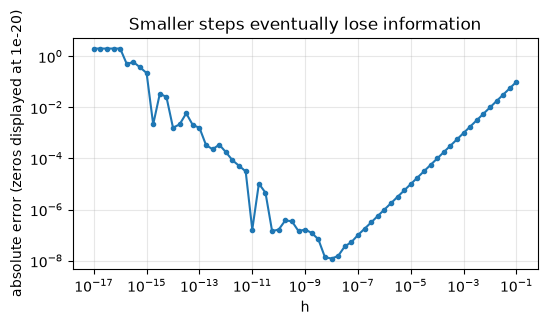

In [14]:
hs = np.logspace(-1, -17, 65)
derivatives = ((1.0 + hs)**2 - 1.0) / hs
errors = abs(derivatives - 2.0)
fig, ax = plt.subplots(figsize=(6, 3))
ax.loglog(hs, np.maximum(errors, 1e-20), marker=".")
ax.set(xlabel="h", ylabel="absolute error (zeros displayed at 1e-20)",
       title="Smaller steps eventually lose information")
ax.grid(alpha=0.3)
display(fig)
plt.close(fig)

## Recap and reading

Error analysis needs an explicit input interpretation and a trustworthy reference.
Reformulation can reduce evaluation error; it does not reduce the underlying
sensitivity to uncertain data. Compensated summation and higher precision are
useful algorithms, but a certificate still needs a justified bound.

**Exit ticket:** explain why the factored polynomial can be evaluated accurately
at a stored float while remaining sensitive to uncertainty in that input. Give
one limitation each of Horner evaluation, the quadratic reformulation, and Kahan
summation.

**Reading:** Tucker §1.6, Examples 1.6.1–1.6.2, pp. 19–21. Read the
[local reference note](../Doc/tucker_chapter1_examples.md) for pointers.
Next: [interval sets and endpoint arithmetic](04_interval_basics.ipynb).